# Joint Probability Distributions


**Question asked:** <span style="color:red;">"What is the probability of every possible combination of variables?" </span>

A joint probability distribution describes uncertainty over two or more
random variables simultaneously.

For two discrete random variables $X$ and $Y$, the joint probability
mass function is

$$p_{xy}(x,y)=P(X=x, Y=y)$$

A valid joint probability distribution satisfies:

1. **Non-negativity:**

$$p_{xy}(x,y)\geq 0$$

2. **Normalization:**

$$\sum_{x} \sum_{y} p_{xy}(x.y) = 1$$ 

**Note** From the joint distribution, we can later derive **marginal distributions,
conditional distributions, expectations, covariance, and independence**.

In [3]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Hashable, Sequence

import matplotlib.pyplot as plt
import numpy as np

In [17]:
@dataclass
class JointDistribution:
    """
    Discrete joint probability distribution over two random variables.

    Parameters
    ----------
    x_values:
        Possible values of the first random variable X.

    y_values:
        Possible values of the second random variable Y.

    probabilities:
        Matrix where probabilities[i, j] represents
        P(X = x_values[i], Y = y_values[j]).
    """

    x_values: Sequence[Hashable]
    y_values: Sequence[Hashable]
    probabilities: np.ndarray

    def __post_init__(self) -> None:
        self.x_values = np.asarray(self.x_values, dtype=object)
        self.y_values  = np.asarray(self.y_values, dtype=object)
        self.probabilities = np.asarray(self.probabilities, dtype=float)

        self._validate_parameters()

        self._x_to_index = {
            value: index for index, value in enumerate(self.x_values)
        }
        self._y_to_index = {
            value: index for index, value in enumerate(self.y_values)
        }

    def _validate_parameters(self) -> None:
        """Validate the values and probability table."""

        if self.x_values.ndim != 1:
            raise ValueError("x_values must be one-dimensional.")

        if self.y_values.ndim != 1:
            raise ValueError("y_values must be one-dimensional.")

        if len(self.x_values) == 0:
            raise ValueError("x_values cannot be empty.")

        if len(self.y_values) == 0:
            raise ValueError("y_values cannot be empty.")

        expected_shape = (len(self.x_values), len(self.y_values))

        if self.probabilities.shape != expected_shape:
            raise ValueError(
                "The probability matrix must have shape "
                f"{expected_shape}, but received "
                f"{self.probabilities.shape}."
            )

        if not np.all(np.isfinite(self.probabilities)):
            raise ValueError("Probabilities must contain only finite values.")

        if np.any(self.probabilities < 0.0):
            raise ValueError("Probabilities cannot be negative.")

        if not np.isclose(self.probabilities.sum(), 1.0):
            raise ValueError(
                "The joint probabilities must sum to 1. "
                f"Received sum={self.probabilities.sum():.6f}."
            )

        if len(set(self.x_values)) != len(self.x_values):
            raise ValueError("x_values must contain unique values.")

        if len(set(self.y_values)) != len(self.y_values):
            raise ValueError("y_values must contain unique values.")

    

    def pmf(self, x: Hashable, y: Hashable) -> float:
        """
        Return P(X=x, Y=y).

        Parameters
        ----------
        x:
            Value of random variable X.

        y:
            Value of random variable Y.
        """

        if x not in self._x_to_index:
            raise ValueError(f"Unknown value for X: {x!r}.")

        if y not in self._y_to_index:
            raise ValueError(f"Unknown value for Y: {y!r}.")

        x_index = self._x_to_index[x]
        y_index = self._y_to_index[y]

        return float(self.probabilities[x_index, y_index])
    
    def sample(
        self,
        size: int =1,
        rng: np.random.Generator | None = None,
    ) -> np.ndarray:
        """
        Draw samples from the joint distribution.

        Returns
        -------
        np.ndarray
            Array of shape (size, 2). Each row contains one sampled
            pair (x, y).
        """

        if not isinstance(size, (int, np.integer)):
            raise TypeError("size must be an integer.")

        if size <= 0:
            raise ValueError("size must be greater than zero.")

        flat_probabilities = self.probabilities.ravel()

        sampled_flat_indices = rng.choice(
            len(flat_probabilities),
            size=size,
            p=flat_probabilities,
        )

        x_indices, y_indices = np.unravel_index(
            sampled_flat_indices,
            self.probabilities.shape,
        )

        samples = np.column_stack(
            (
                self.x_values[x_indices],
                self.y_values[y_indices],
            )
        )

        return samples

    def plot_heatmap(
        self,
        x_label: str = "X",
        y_label: str = "Y",
    ) -> None:
        """Plot the joint probability table as a heatmap."""

        fig, ax = plt.subplots(figsize=(7, 5))

        image = ax.imshow(self.probabilities)

        ax.set_xticks(np.arange(len(self.y_values)))
        ax.set_yticks(np.arange(len(self.x_values)))

        ax.set_xticklabels(self.y_values)
        ax.set_yticklabels(self.x_values)

        ax.set_xlabel(y_label)
        ax.set_ylabel(x_label)
        ax.set_title("Joint Probability Distribution")

        for i in range(len(self.x_values)):
            for j in range(len(self.y_values)):
                probability = self.probabilities[i, j]

                ax.text(
                    j,
                    i,
                    f"{probability:.2f}",
                    ha="center",
                    va="center",
                )

        fig.colorbar(image, ax=ax, label="Probability")
        plt.tight_layout()
        plt.show()

    def expectation(self, function) -> float:
        """
        Calculate E[g(X, Y)] for a supplied function g.
        """

        expected_value = 0.0

        for i, x in enumerate(self.x_values):
            for j, y in enumerate(self.y_values):
                expected_value += (
                    function(x, y)
                    * self.probabilities[i, j]
                )

        return float(expected_value)

In [18]:
weather_traffic = JointDistribution(
    x_values=["sunny", "rainy"],
    y_values=["light", "heavy"],
    probabilities=[
        [0.40, 0.10],
        [0.20, 0.30],
    ],
)
rng = np.random.default_rng(seed=42)

samples = weather_traffic.sample(size=10, rng=rng)
samples

array([['rainy', 'heavy'],
       ['sunny', 'heavy'],
       ['rainy', 'heavy'],
       ['rainy', 'light'],
       ['sunny', 'light'],
       ['rainy', 'heavy'],
       ['rainy', 'heavy'],
       ['rainy', 'heavy'],
       ['sunny', 'light'],
       ['sunny', 'heavy']], dtype=object)

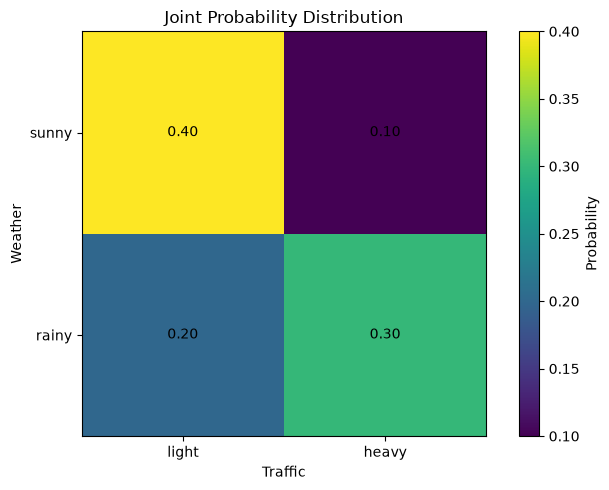

In [19]:
weather_traffic.plot_heatmap(
    x_label="Weather",
    y_label="Traffic",
)

In [20]:
def travel_delay(weather: str, traffic: str) -> float:
    delays = {
        ("sunny", "light"): 10.0,
        ("sunny", "heavy"): 30.0,
        ("rainy", "light"): 20.0,
        ("rainy", "heavy"): 50.0,
    }

    return delays[(weather, traffic)]

In [21]:
expected_delay = weather_traffic.expectation(travel_delay)

print("Expected travel delay:", expected_delay)

Expected travel delay: 26.0
